# Учебный проект: кредитный скоринг (PD-модель) на данных German Credit

**Задача.** По анкете заёмщика предсказать вероятность дефолта (PD, probability of default) — что клиент не вернёт кредит.
На основе модели построить скоринговую карту (баллы), выбрать порог одобрения и настроить мониторинг стабильности модели.

**Почему именно так.** В кредитном скоринге стандарт — логистическая регрессия на WoE-преобразованных признаках:
она интерпретируема (видно вклад каждого признака), монотонна и легко превращается в баллы. Сложные модели (бустинг) используются как ориентир —
насколько качества мы теряем ради интерпретируемости.

**Данные.** Открытый датасет German Credit (UCI): 1000 кредитов, 20 признаков анкеты, целевая переменная — хороший/плохой заёмщик.

---
# 1. Исходные данные
### 1.1 Загрузка библиотек и данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve

SEED = 42
URL = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"
df = pd.read_csv(URL)
df.shape

(1000, 21)

### 1.2 Описание данных и целевой переменной

В исходных данных `credit_risk = 1` — хороший заёмщик, `0` — плохой. В скоринге принято моделировать **событие дефолта**,
поэтому заводим целевую переменную `bad = 1`, если заёмщик плохой. Модель будет выдавать вероятность дефолта.

In [2]:
df["bad"] = 1 - df["credit_risk"]
df = df.drop(columns="credit_risk")

print("Доля дефолтов (bad rate):", round(df["bad"].mean(), 3))
df.dtypes

Доля дефолтов (bad rate): 0.3


status                       str
duration                   int64
credit_history               str
purpose                      str
amount                     int64
savings                      str
employment_duration          str
installment_rate           int64
personal_status_sex          str
other_debtors                str
present_residence          int64
property                     str
age                        int64
other_installment_plans      str
housing                      str
number_credits             int64
job                          str
people_liable              int64
telephone                    str
foreign_worker               str
bad                        int64
dtype: object

Bad rate 30% — классы несбалансированы, но не сильно. Поэтому **accuracy не подходит**: модель «все хорошие» дала бы 70%.
В скоринге основная метрика — **Gini = 2·ROC-AUC − 1**: насколько хорошо модель ранжирует клиентов от надёжных к рискованным.
Gini 0 — случайное угадывание, 1 — идеальное разделение.

### 1.3 Первичный анализ: уровень дефолтов по категориям

In [3]:
cat_cols = df.select_dtypes(exclude="number").columns.tolist()
num_cols = [c for c in df.select_dtypes("number").columns if c != "bad"]
print("Категориальные:", len(cat_cols), "| Числовые:", len(num_cols))

for col in ["status", "credit_history", "savings"]:
    t = df.groupby(col)["bad"].agg(["count", "mean"]).rename(columns={"mean": "bad_rate"})
    print(f"\n{col}\n", t.sort_values("bad_rate").round(3))

Категориальные: 13 | Числовые: 7

status
                                             count  bad_rate
status                                                     
no checking account                           394     0.117
... >= 200 DM / salary for at least 1 year     63     0.222
0 <= ... < 200 DM                             269     0.390
... < 100 DM                                  274     0.493

credit_history
                                              count  bad_rate
credit_history                                              
critical account/other credits existing        293     0.171
delay in paying off in the past                 88     0.318
existing credits paid back duly till now       530     0.319
all credits at this bank paid back duly         49     0.571
no credits taken/all credits paid back duly     40     0.625

savings
                             count  bad_rate
savings                                    
... >= 1000 DM                 48     0.125
500 <= ... <

Уже видно, что признаки сильно разделяют риск: например, у клиентов без текущего счёта (`no checking account`) дефолтов заметно меньше,
чем у клиентов с отрицательным балансом. Именно такие различия модель и будет использовать.

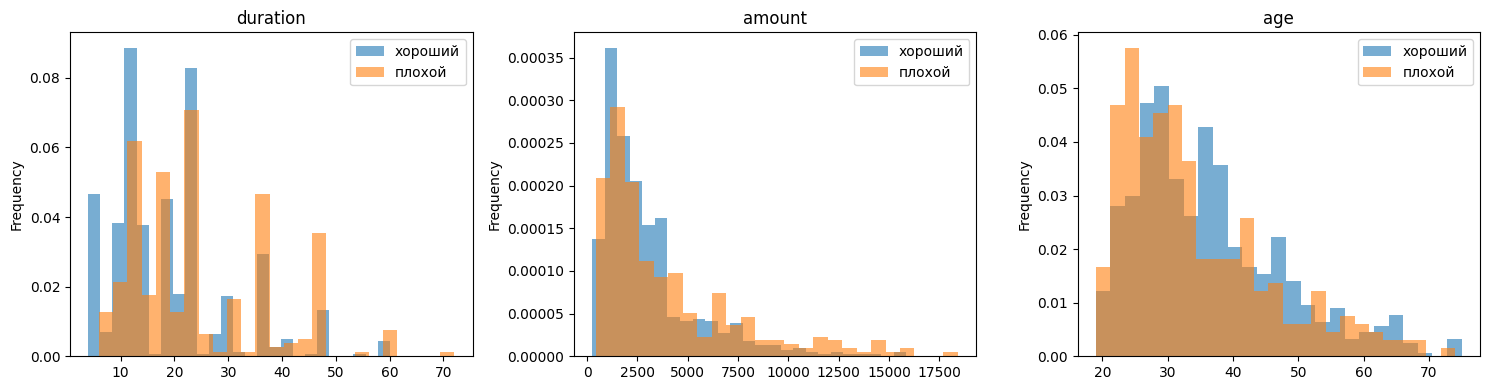

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["duration", "amount", "age"]):
    df[df.bad == 0][col].plot.hist(ax=ax, bins=25, alpha=.6, density=True, label="хороший")
    df[df.bad == 1][col].plot.hist(ax=ax, bins=25, alpha=.6, density=True, label="плохой")
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

Длинные и крупные кредиты чаще уходят в дефолт; молодые заёмщики — чуть рискованнее.

---
# 2. Предобработка
### 2.1 Разбиение на обучение и тест

In [5]:
X = df.drop(columns="bad")
y = df["bad"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED)
print(X_train.shape, X_test.shape, "| bad rate:", round(y_train.mean(), 3), round(y_test.mean(), 3))

(700, 20) (300, 20) | bad rate: 0.3 0.3


`stratify=y` сохраняет одинаковую долю дефолтов в обучении и тесте.
**Важно:** все преобразования (границы бинов, WoE) считаем **только на обучающей выборке**, а на тест только применяем.
Иначе информация из теста «протечёт» в модель, и оценка качества будет завышена (data leakage).

### 2.2 WoE-преобразование и Information Value

**Биннинг.** Числовые признаки делим на интервалы (здесь — по квантилям, 5 бинов), у категориальных редкие категории (<5%) объединяем в `other`.

**WoE (Weight of Evidence)** для каждого бина:  
$WoE = \ln\frac{доля\ хороших\ в\ бине}{доля\ плохих\ в\ бине}$

Положительный WoE — в бине больше хороших, чем в среднем; отрицательный — больше плохих.
Заменяя значение признака на WoE его бина, мы получаем признак, **линейно связанный с log-odds дефолта** — ровно то, что нужно логистической регрессии.
Заодно решаются проблемы выбросов (крайние значения попадают в крайний бин) и категориальных признаков (не нужен one-hot).

**IV (Information Value)** — сила признака:  
$IV = \sum (доля\ хороших - доля\ плохих)\cdot WoE$

Ориентиры: < 0.02 — бесполезный, 0.02–0.1 — слабый, 0.1–0.3 — средний, > 0.3 — сильный.

In [6]:
LOW_CARD = [c for c in num_cols if X_train[c].nunique() <= 5]   # числовые с малым числом значений — как категории
NUM_BIN = [c for c in num_cols if c not in LOW_CARD]

def make_bins(x, col):
    """Правила биннинга по обучающей выборке."""
    if col in NUM_BIN:
        _, edges = pd.qcut(x, q=5, retbins=True, duplicates="drop")
        edges[0], edges[-1] = -np.inf, np.inf
        return ("num", edges)
    share = x.astype(str).value_counts(normalize=True)
    keep = share[share >= 0.05].index.tolist()
    return ("cat", keep)

def apply_bins(x, rule):
    kind, p = rule
    if kind == "num":
        return pd.cut(x, bins=p).astype(str)
    x = x.astype(str)
    return x.where(x.isin(p), "other")

def woe_table(binned, target):
    t = pd.DataFrame({"bin": binned, "bad": target}).groupby("bin")["bad"].agg(["count", "sum"])
    t.columns = ["n", "bad"]
    t["good"] = t["n"] - t["bad"]
    dg = (t["good"] + 0.5) / (t["good"].sum() + 0.5)   # +0.5 — сглаживание, чтобы не было log(0)
    db = (t["bad"] + 0.5) / (t["bad"].sum() + 0.5)
    t["bad_rate"] = t["bad"] / t["n"]
    t["woe"] = np.log(dg / db)
    t["iv_part"] = (dg - db) * t["woe"]
    return t

rules, woe_maps, iv = {}, {}, {}
for col in X_train.columns:
    rules[col] = make_bins(X_train[col], col)
    t = woe_table(apply_bins(X_train[col], rules[col]), y_train)
    woe_maps[col] = t["woe"].to_dict()
    iv[col] = t["iv_part"].sum()

iv = pd.Series(iv).sort_values(ascending=False)
iv.round(3)

status                     0.633
credit_history             0.254
savings                    0.223
duration                   0.185
employment_duration        0.140
property                   0.139
purpose                    0.127
other_installment_plans    0.118
housing                    0.103
foreign_worker             0.066
amount                     0.064
age                        0.047
personal_status_sex        0.040
installment_rate           0.033
job                        0.024
number_credits             0.004
telephone                  0.003
present_residence          0.002
other_debtors              0.001
people_liable              0.000
dtype: float64

In [7]:
print(woe_table(apply_bins(X_train["status"], rules["status"]), y_train)[["n", "bad_rate", "woe"]].round(3))
print()
print(woe_table(apply_bins(X_train["duration"], rules["duration"]), y_train)[["n", "bad_rate", "woe"]].round(3))

                                              n  bad_rate    woe
bin                                                             
... < 100 DM                                192     0.479 -0.763
... >= 200 DM / salary for at least 1 year   44     0.273  0.110
0 <= ... < 200 DM                           188     0.394 -0.416
no checking account                         276     0.116  1.172

                n  bad_rate    woe
bin                               
(-inf, 12.0]  260     0.208  0.486
(12.0, 15.0]   49     0.204  0.479
(15.0, 24.0]  230     0.343 -0.201
(24.0, 30.0]   40     0.325 -0.134
(30.0, inf]   121     0.446 -0.632


Видно логику WoE: чем выше bad rate в бине, тем ниже WoE. У `duration` WoE монотонно падает с ростом срока кредита —
это бизнесово понятно и именно такую монотонность проверяют при валидации скоринговых моделей.

### 2.3 Отбор признаков по IV

Оставляем признаки с IV ≥ 0.02. Дополнительно **исключаем пол/семейное положение и признак иностранного работника**:
даже если они предсказательны, решение о кредите не должно зависеть от таких характеристик — это вопрос недискриминации и требований регулятора.

In [8]:
SENSITIVE = ["personal_status_sex", "foreign_worker"]   # пол/семейный статус и гражданство
selected = [c for c in iv[iv >= 0.02].index if c not in SENSITIVE]
print(f"Отобрано {len(selected)} из {len(iv)} признаков:", selected)

def to_woe(X_part):
    out = pd.DataFrame(index=X_part.index)
    for col in selected:
        b = apply_bins(X_part[col], rules[col])
        out[col] = b.map(woe_maps[col]).fillna(0.0)   # неизвестный бин -> WoE 0 (нейтрально)
    return out

W_train, W_test = to_woe(X_train), to_woe(X_test)
W_train.head()

Отобрано 13 из 20 признаков: ['status', 'credit_history', 'savings', 'duration', 'employment_duration', 'property', 'purpose', 'other_installment_plans', 'housing', 'amount', 'age', 'installment_rate', 'job']


,status,credit_history,savings,duration,employment_duration,property,purpose,other_installment_plans,housing,amount,age,installment_rate,job
10,-0.416164,-0.083800,-0.301799,0.486160,-0.579919,-0.037343,-0.183164,0.173837,-0.470628,0.329265,-0.352064,-0.105961,0.038676
82,1.172036,-0.083800,-0.106701,-0.201111,0.071769,0.046411,-0.226900,0.173837,-0.470628,0.329265,-0.352064,-0.105961,0.097819
827,1.172036,-1.123571,-0.301799,-0.201111,0.071769,-0.037343,-0.226900,-0.321415,0.213297,0.169291,0.136262,0.205605,0.038676
410,-0.416164,-0.083800,-0.301799,-0.201111,0.188821,-0.037343,0.377836,0.173837,0.213297,0.018423,-0.352064,-0.150470,0.038676
48,1.172036,0.689601,-0.301799,0.486160,0.071769,0.046411,-0.183164,0.173837,0.213297,-0.413806,0.252673,0.279520,0.097819


---
# 3. Модель
### 3.1 Логистическая регрессия на WoE

In [9]:
logreg = LogisticRegression(C=1.0, max_iter=1000)
logreg.fit(W_train, y_train)

p_train = logreg.predict_proba(W_train)[:, 1]
p_test = logreg.predict_proba(W_test)[:, 1]
gini = lambda y_true, p: 2 * roc_auc_score(y_true, p) - 1

print(f"Gini train: {gini(y_train, p_train):.3f}")
print(f"Gini test:  {gini(y_test, p_test):.3f}")

cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
cv_auc = cross_val_score(LogisticRegression(max_iter=1000), W_train, y_train, cv=cv, scoring="roc_auc")
print(f"Gini на кросс-валидации: {np.mean(2*cv_auc-1):.3f} ± {np.std(2*cv_auc-1):.3f}")

Gini train: 0.629
Gini test:  0.588
Gini на кросс-валидации: 0.592 ± 0.052


Разница между train и test небольшая — модель не переобучилась.
Кросс-валидация показывает разброс Gini на разных подвыборках: при 700 объектах в обучении он заметный, это нормально для маленьких данных.

**Проверка коэффициентов.** Так как WoE растёт вместе с долей хороших, а модель предсказывает дефолт,
все коэффициенты должны быть **отрицательными**. Положительный коэффициент — сигнал проблемы (обычно мультиколлинеарность).

In [10]:
coefs = pd.Series(logreg.coef_[0], index=selected).sort_values()
print(coefs.round(3))
print("\nПоложительных коэффициентов:", (coefs > 0).sum())

installment_rate          -1.277
purpose                   -0.869
duration                  -0.846
savings                   -0.837
employment_duration       -0.775
status                    -0.756
other_installment_plans   -0.692
credit_history            -0.631
age                       -0.567
housing                   -0.469
amount                    -0.467
property                  -0.364
job                        0.314
dtype: float64

Положительных коэффициентов: 1


Если есть признак с положительным коэффициентом, убираем его и переобучаем модель.
Обычно это слабый признак, который дублирует информацию других (мультиколлинеарность), и его знак нельзя объяснить бизнесу.

In [11]:
wrong_sign = coefs[coefs > 0].index.tolist()
print("Убираем:", wrong_sign)
selected = [c for c in selected if c not in wrong_sign]
W_train, W_test = to_woe(X_train), to_woe(X_test)

logreg = LogisticRegression(C=1.0, max_iter=1000).fit(W_train, y_train)
p_train = logreg.predict_proba(W_train)[:, 1]
p_test = logreg.predict_proba(W_test)[:, 1]
print(f"Признаков в модели: {len(selected)}")
print(f"Gini train: {gini(y_train, p_train):.3f} | Gini test: {gini(y_test, p_test):.3f}")
print("Все коэффициенты отрицательные:", (logreg.coef_[0] < 0).all())

Убираем: ['job']


Признаков в модели: 12
Gini train: 0.629 | Gini test: 0.586
Все коэффициенты отрицательные: True


### 3.2 KS и ROC-кривая

**KS (Колмогоров–Смирнов)** — максимальное расстояние между накопленными распределениями скора у хороших и плохих.
Вторая стандартная метрика в скоринге рядом с Gini.

KS test: 0.468


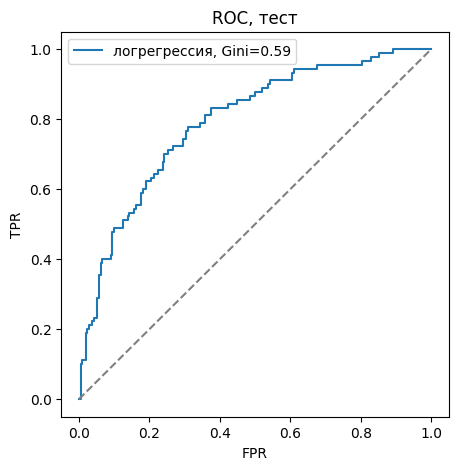

In [12]:
fpr, tpr, _ = roc_curve(y_test, p_test)
ks = np.max(tpr - fpr)
print(f"KS test: {ks:.3f}")

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"логрегрессия, Gini={gini(y_test, p_test):.2f}")
plt.plot([0, 1], [0, 1], "--", color="grey")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC, тест"); plt.legend(); plt.show()

### 3.3 Сравнение с градиентным бустингом

Бустинг — сильная «чёрная коробка». Его Gini показывает, сколько качества теоретически можно добрать.
Если разница маленькая — выбираем интерпретируемую логрегрессию.

In [13]:
boost = Pipeline([
    ("prep", ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
                               remainder="passthrough", sparse_threshold=0)),
    ("model", HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05,
                                             max_depth=3, random_state=SEED)),
])
boost.fit(X_train, y_train)
p_boost = boost.predict_proba(X_test)[:, 1]
print(f"Gini бустинг test:     {gini(y_test, p_boost):.3f}")
print(f"Gini логрегрессия test: {gini(y_test, p_test):.3f}")

Gini бустинг test:     0.538
Gini логрегрессия test: 0.586


На таком маленьком и «табличном» датасете бустинг не даёт преимущества. Вывод: оставляем логрегрессию —
она не хуже по качеству, при этом объяснима для риск-менеджеров и регулятора.

### 3.4 Скоринговая карта (перевод в баллы)

Вероятность дефолта переводят в баллы по стандартной формуле:  
$Score = Offset + Factor \cdot \ln(odds_{good})$, где $Factor = PDO / \ln 2$.

Параметры (договорённость, а не результат обучения): 600 баллов соответствуют шансам 50:1 (хороший:плохой), **PDO = 20** —
каждые +20 баллов удваивают шансы клиента оказаться хорошим. Чем выше балл, тем надёжнее клиент.

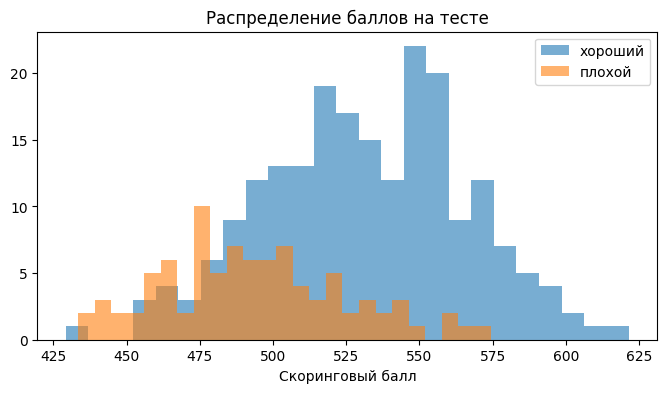

In [14]:
PDO, BASE_SCORE, BASE_ODDS = 20, 600, 50
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

def to_score(p_bad):
    return offset + factor * np.log((1 - p_bad) / p_bad)

s_train, s_test = to_score(p_train), to_score(p_test)

plt.figure(figsize=(8, 4))
plt.hist(s_test[y_test == 0], bins=25, alpha=.6, label="хороший")
plt.hist(s_test[y_test == 1], bins=25, alpha=.6, label="плохой")
plt.xlabel("Скоринговый балл"); plt.legend(); plt.title("Распределение баллов на тесте"); plt.show()

### 3.5 Выбор порога одобрения

Модель не решает, кому давать кредит, — это бизнес-решение. Таблица показывает компромисс:
чем выше порог, тем меньше одобряем, но тем ниже доля плохих среди одобренных.

In [15]:
rows = []
for q in [0.1, 0.2, 0.3, 0.4, 0.5]:
    cutoff = np.quantile(s_test, q)
    approved = s_test >= cutoff
    rows.append({"порог (балл)": round(cutoff),
                 "одобрено": f"{approved.mean():.0%}",
                 "bad rate среди одобренных": f"{y_test[approved].mean():.1%}"})
pd.DataFrame(rows)

,порог (балл),одобрено,bad rate среди одобренных
0,472,90%,25.6%
1,486,80%,20.8%
2,498,70%,17.6%
3,509,60%,14.4%
4,520,50%,11.3%


Для сравнения: без модели bad rate в портфеле ~30%. Отказывая самым рискованным клиентам, модель заметно снижает долю дефолтов.

---
# 4. Мониторинг стабильности (PSI)

После внедрения модель работает на новых клиентах, и их профиль может «уехать» от обучающей выборки.
**PSI (Population Stability Index)** сравнивает распределения:  
$PSI = \sum (факт - ожид) \cdot \ln\frac{факт}{ожид}$ по бинам.

Ориентиры: < 0.1 — стабильно, 0.1–0.25 — есть сдвиг, > 0.25 — модель нужно перепроверять или перестраивать.
Здесь сравниваем train и test; в реальности сравнивают выборку разработки с каждым новым месяцем.

In [16]:
def psi(expected, actual, bins=10):
    edges = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    e = np.histogram(expected, edges)[0] / len(expected)
    a = np.histogram(actual, edges)[0] / len(actual)
    e, a = np.clip(e, 1e-6, None), np.clip(a, 1e-6, None)
    return np.sum((a - e) * np.log(a / e))

print(f"PSI скорингового балла: {psi(s_train, s_test):.3f}")
feat_psi = pd.Series({c: psi(W_train[c].values, W_test[c].values, bins=5) for c in selected})
feat_psi.sort_values(ascending=False).round(3).head(8)

PSI скорингового балла: 0.012


employment_duration    0.019
amount                 0.019
credit_history         0.013
age                    0.013
installment_rate       0.012
purpose                0.009
savings                0.006
duration               0.006
dtype: float64

---
# 5. Выводы

1. Построена PD-модель: логистическая регрессия на WoE-признаках, отбор признаков по IV.
2. Качество на тесте сопоставимо с бустингом, поэтому выбрана интерпретируемая модель — стандарт для кредитного скоринга.
3. Вероятность переведена в баллы (PDO = 20), показан выбор порога одобрения через компромисс «доля одобрений — bad rate».
4. Реализован расчёт PSI для мониторинга стабильности модели и признаков.

**Что можно улучшить:**
- биннинг с оптимизацией (например, по дереву решений) и принудительной монотонностью WoE;
- проверка мультиколлинеарности (VIF, корреляции WoE-признаков);
- out-of-time валидация — тест на более поздних по времени выдачах (в этих данных нет дат);
- калибровка вероятностей под фактический уровень дефолтов портфеля;
- автоматизация: пересчёт PSI по расписанию и сигнал, когда модель пора перестраивать.